In [1]:

import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('summary_bulk_and_gev.csv')
print("Data loaded successfully:")
print(df)
print("\n" + "="*80 + "\n")


Data loaded successfully:
 Function Mean Variance Skewness Excess_Kurtosis \
0 F1: Riemann ζ 0.024813 1.612150 -0.680783 0.757592 
1 F2: L(χ₄) real mod 5 0.007661 1.665577 -0.829473 1.620789 
2 F3: L(χ) complex mod 5 0.002237 1.689893 -0.814897 1.289572 
3 F4: Random multiplicative 0.300001 0.917201 -0.028413 0.351658 
4 F5: Davenport-Heilbronn 0.538504 0.721576 -0.489109 0.724587 
5 F6: Liouville L(s,λ) 0.298472 0.952970 -0.083103 0.295221 
6 F7: Möbius L(s,μ) 0.275954 0.932475 -0.385594 0.192694 
7 F8: Fully random 0.960181 0.407649 -1.146475 2.419105 

 xi_shape xi_SE xi_CI_lower xi_CI_upper 
0 -0.372965 0.024276 -0.420545 -0.325385 
1 -0.319997 0.028342 -0.375547 -0.264447 
2 -0.267277 0.034377 -0.334657 -0.199898 
3 -0.223911 0.032517 -0.287644 -0.160178 
4 -0.314893 0.030726 -0.375116 -0.254671 
5 -0.184682 0.034735 -0.252762 -0.116602 
6 -0.243025 0.027951 -0.297808 -0.188241 
7 -1.369802 0.000000 -1.369802 -1.369802 




In [2]:

# Add RH status based on the known classification
# RH-satisfying (True): F1 (Riemann ζ), F2 (L(χ₄) real mod 5), F7 (Möbius L(s,μ))
# RH-violating (False): F3, F4, F5, F6, F8

rh_status = {
 'F1: Riemann ζ': True,
 'F2: L(χ₄) real mod 5': True,
 'F3: L(χ) complex mod 5': False,
 'F4: Random multiplicative': False,
 'F5: Davenport-Heilbronn': False,
 'F6: Liouville L(s,λ)': False,
 'F7: Möbius L(s,μ)': True,
 'F8: Fully random': False
}

df['RH_Status'] = df['Function'].map(rh_status)

print("Dataset with RH Status:")
print(df[['Function', 'RH_Status']])
print("\n" + "="*80 + "\n")
print(f"RH-satisfying functions (True): {df['RH_Status'].sum()}")
print(f"RH-violating functions (False): {(~df['RH_Status']).sum()}")
print("\n" + "="*80 + "\n")


Dataset with RH Status:
 Function RH_Status
0 F1: Riemann ζ True
1 F2: L(χ₄) real mod 5 True
2 F3: L(χ) complex mod 5 False
3 F4: Random multiplicative False
4 F5: Davenport-Heilbronn False
5 F6: Liouville L(s,λ) False
6 F7: Möbius L(s,μ) True
7 F8: Fully random False


RH-satisfying functions (True): 3
RH-violating functions (False): 5




In [3]:

# Prepare features: Variance, Skewness, Excess_Kurtosis
features = ['Variance', 'Skewness', 'Excess_Kurtosis']
X = df[features].values
y = df['RH_Status'].values

print("Features (X):")
print(pd.DataFrame(X, columns=features, index=df['Function']))
print("\n" + "="*80 + "\n")
print("Target (y - RH Status):")
print(pd.DataFrame({'Function': df['Function'], 'RH_Status': y}))
print("\n" + "="*80 + "\n")


Features (X):
 Variance Skewness Excess_Kurtosis
Function 
F1: Riemann ζ 1.612150 -0.680783 0.757592
F2: L(χ₄) real mod 5 1.665577 -0.829473 1.620789
F3: L(χ) complex mod 5 1.689893 -0.814897 1.289572
F4: Random multiplicative 0.917201 -0.028413 0.351658
F5: Davenport-Heilbronn 0.721576 -0.489109 0.724587
F6: Liouville L(s,λ) 0.952970 -0.083103 0.295221
F7: Möbius L(s,μ) 0.932475 -0.385594 0.192694
F8: Fully random 0.407649 -1.146475 2.419105


Target (y - RH Status):
 Function RH_Status
0 F1: Riemann ζ True
1 F2: L(χ₄) real mod 5 True
2 F3: L(χ) complex mod 5 False
3 F4: Random multiplicative False
4 F5: Davenport-Heilbronn False
5 F6: Liouville L(s,λ) False
6 F7: Möbius L(s,μ) True
7 F8: Fully random False




In [4]:

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardized Features (X_scaled):")
print(pd.DataFrame(X_scaled, columns=features, index=df['Function']))
print("\n" + "="*80 + "\n")
print("Feature mean (should be ~0):", X_scaled.mean(axis=0))
print("Feature std (should be ~1):", X_scaled.std(axis=0))
print("\n" + "="*80 + "\n")


Standardized Features (X_scaled):
 Variance Skewness Excess_Kurtosis
Function 
F1: Riemann ζ 1.105517 -0.342421 -0.275327
F2: L(χ₄) real mod 5 1.223713 -0.754509 0.920089
F3: L(χ) complex mod 5 1.277507 -0.714113 0.461397
F4: Random multiplicative -0.431919 1.465601 -0.837492
F5: Davenport-Heilbronn -0.864701 0.188797 -0.321034
F6: Liouville L(s,λ) -0.352788 1.314031 -0.915651
F7: Möbius L(s,μ) -0.398129 0.475687 -1.057636
F8: Fully random -1.559200 -1.633071 2.025655


Feature mean (should be ~0): [1.11022302e-16 6.93889390e-17 0.00000000e+00]
Feature std (should be ~1): [1. 1. 1.]




In [5]:

# Train SVM with RBF kernel and perform LOOCV
svm_model = SVC(kernel='rbf', gamma='scale', random_state=42)

# Leave-one-out cross-validation
loo = LeaveOneOut()

# Get LOOCV predictions
y_pred_loocv = cross_val_predict(svm_model, X_scaled, y, cv=loo)

# Calculate LOOCV metrics
loocv_accuracy = accuracy_score(y, y_pred_loocv)
loocv_precision = precision_score(y, y_pred_loocv, zero_division=0)
loocv_recall = recall_score(y, y_pred_loocv, zero_division=0)
loocv_f1 = f1_score(y, y_pred_loocv, zero_division=0)
loocv_confusion = confusion_matrix(y, y_pred_loocv)

print("="*80)
print("SVM CLASSIFIER PERFORMANCE (LEAVE-ONE-OUT CROSS-VALIDATION)")
print("="*80)
print(f"\nLOOCV Accuracy: {loocv_accuracy:.4f} ({loocv_accuracy*100:.2f}%)")
print(f"LOOCV Precision: {loocv_precision:.4f}")
print(f"LOOCV Recall: {loocv_recall:.4f}")
print(f"LOOCV F1-Score: {loocv_f1:.4f}")
print("\n" + "="*80 + "\n")

print("Confusion Matrix (LOOCV):")
print(" Predicted False Predicted True")
print(f"Actual False {loocv_confusion[0,0]} {loocv_confusion[0,1]}")
print(f"Actual True {loocv_confusion[1,0]} {loocv_confusion[1,1]}")
print("\n" + "="*80 + "\n")


SVM CLASSIFIER PERFORMANCE (LEAVE-ONE-OUT CROSS-VALIDATION)

LOOCV Accuracy: 0.5000 (50.00%)
LOOCV Precision: 0.0000
LOOCV Recall: 0.0000
LOOCV F1-Score: 0.0000


Confusion Matrix (LOOCV):
 Predicted False Predicted True
Actual False 4 1
Actual True 3 0




In [6]:

# Detailed analysis: which functions were misclassified?
results_df = pd.DataFrame({
 'Function': df['Function'],
 'True_RH_Status': y,
 'Predicted_RH_Status': y_pred_loocv,
 'Correct': y == y_pred_loocv
})

print("LOOCV Predictions by Function:")
print("="*80)
print(results_df.to_string(index=False))
print("\n" + "="*80 + "\n")

print("Misclassified Functions:")
misclassified = results_df[~results_df['Correct']]
print(misclassified[['Function', 'True_RH_Status', 'Predicted_RH_Status']].to_string(index=False))
print("\n" + "="*80 + "\n")


LOOCV Predictions by Function:
 Function True_RH_Status Predicted_RH_Status Correct
 F1: Riemann ζ True False False
 F2: L(χ₄) real mod 5 True False False
 F3: L(χ) complex mod 5 False True False
F4: Random multiplicative False False True
 F5: Davenport-Heilbronn False False True
 F6: Liouville L(s,λ) False False True
 F7: Möbius L(s,μ) True False False
 F8: Fully random False False True


Misclassified Functions:
 Function True_RH_Status Predicted_RH_Status
 F1: Riemann ζ True False
 F2: L(χ₄) real mod 5 True False
F3: L(χ) complex mod 5 False True
 F7: Möbius L(s,μ) True False




In [7]:

# Let's explore the feature space to understand why the classifier fails
print("Feature Space Analysis:")
print("="*80)
print("\nRH-Satisfying Functions (True):")
rh_true_df = df[df['RH_Status'] == True][['Function'] + features]
print(rh_true_df.to_string(index=False))
print("\nMean for RH-True:", df[df['RH_Status'] == True][features].mean().values)
print("Std for RH-True:", df[df['RH_Status'] == True][features].std().values)

print("\n" + "-"*80 + "\n")

print("RH-Violating Functions (False):")
rh_false_df = df[df['RH_Status'] == False][['Function'] + features]
print(rh_false_df.to_string(index=False))
print("\nMean for RH-False:", df[df['RH_Status'] == False][features].mean().values)
print("Std for RH-False:", df[df['RH_Status'] == False][features].std().values)

print("\n" + "="*80 + "\n")


Feature Space Analysis:

RH-Satisfying Functions (True):
 Function Variance Skewness Excess_Kurtosis
 F1: Riemann ζ 1.612150 -0.680783 0.757592
F2: L(χ₄) real mod 5 1.665577 -0.829473 1.620789
 F7: Möbius L(s,μ) 0.932475 -0.385594 0.192694

Mean for RH-True: [ 1.40340086 -0.63195009 0.85702481]
Std for RH-True: [0.4087078 0.22593283 0.71922078]

--------------------------------------------------------------------------------

RH-Violating Functions (False):
 Function Variance Skewness Excess_Kurtosis
 F3: L(χ) complex mod 5 1.689893 -0.814897 1.289572
F4: Random multiplicative 0.917201 -0.028413 0.351658
 F5: Davenport-Heilbronn 0.721576 -0.489109 0.724587
 F6: Liouville L(s,λ) 0.952970 -0.083103 0.295221
 F8: Fully random 0.407649 -1.146475 2.419105

Mean for RH-False: [ 0.93785773 -0.51239968 1.01602851]
Std for RH-False: [0.47278712 0.47766035 0.87882613]




In [8]:

# Try different SVM kernels to see if performance improves
from sklearn.svm import SVC

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
results = []

for kernel in kernels:
 if kernel == 'poly':
 svm = SVC(kernel=kernel, degree=2, gamma='scale', random_state=42)
 else:
 svm = SVC(kernel=kernel, gamma='scale', random_state=42)
 
 y_pred = cross_val_predict(svm, X_scaled, y, cv=loo)
 acc = accuracy_score(y, y_pred)
 prec = precision_score(y, y_pred, zero_division=0)
 rec = recall_score(y, y_pred, zero_division=0)
 f1 = f1_score(y, y_pred, zero_division=0)
 
 results.append({
 'Kernel': kernel,
 'Accuracy': acc,
 'Precision': prec,
 'Recall': rec,
 'F1-Score': f1
 })

results_df_kernels = pd.DataFrame(results)
print("SVM Performance Across Different Kernels (LOOCV):")
print("="*80)
print(results_df_kernels.to_string(index=False))
print("\n" + "="*80 + "\n")


SVM Performance Across Different Kernels (LOOCV):
 Kernel Accuracy Precision Recall F1-Score
 linear 0.500 0.0 0.0 0.0
 rbf 0.500 0.0 0.0 0.0
 poly 0.375 0.0 0.0 0.0
sigmoid 0.500 0.0 0.0 0.0




In [9]:

# Let's check what the linear SVM is doing
svm_linear = SVC(kernel='linear', random_state=42)
y_pred_linear = cross_val_predict(svm_linear, X_scaled, y, cv=loo)

results_linear = pd.DataFrame({
 'Function': df['Function'],
 'True_RH_Status': y,
 'Predicted_Linear': y_pred_linear,
 'Correct': y == y_pred_linear
})

print("Linear SVM LOOCV Predictions:")
print("="*80)
print(results_linear.to_string(index=False))
print("\n" + "="*80 + "\n")

conf_linear = confusion_matrix(y, y_pred_linear)
print("Confusion Matrix (Linear SVM):")
print(" Predicted False Predicted True")
print(f"Actual False {conf_linear[0,0]} {conf_linear[0,1]}")
print(f"Actual True {conf_linear[1,0]} {conf_linear[1,1]}")
print("\n" + "="*80 + "\n")


Linear SVM LOOCV Predictions:
 Function True_RH_Status Predicted_Linear Correct
 F1: Riemann ζ True False False
 F2: L(χ₄) real mod 5 True False False
 F3: L(χ) complex mod 5 False True False
F4: Random multiplicative False False True
 F5: Davenport-Heilbronn False False True
 F6: Liouville L(s,λ) False False True
 F7: Möbius L(s,μ) True False False
 F8: Fully random False False True


Confusion Matrix (Linear SVM):
 Predicted False Predicted True
Actual False 4 1
Actual True 3 0




In [10]:

# Let's check if there's clear separation in pairwise feature spaces
from scipy.stats import mannwhitneyu

print("Mann-Whitney U Test: RH-True vs RH-False for each feature")
print("="*80)

for feature in features:
 rh_true_vals = df[df['RH_Status'] == True][feature].values
 rh_false_vals = df[df['RH_Status'] == False][feature].values
 
 stat, pval = mannwhitneyu(rh_true_vals, rh_false_vals, alternative='two-sided')
 
 print(f"\n{feature}:")
 print(f" RH-True: {rh_true_vals} (n={len(rh_true_vals)})")
 print(f" RH-False: {rh_false_vals} (n={len(rh_false_vals)})")
 print(f" U-statistic: {stat:.4f}")
 print(f" p-value: {pval:.4f}")
 print(f" Significant at α=0.05: {pval < 0.05}")

print("\n" + "="*80 + "\n")


Mann-Whitney U Test: RH-True vs RH-False for each feature

Variance:
 RH-True: [1.6121505 1.66557721 0.93247488] (n=3)
 RH-False: [1.68989286 0.91720094 0.72157594 0.95296955 0.40764936] (n=5)
 U-statistic: 11.0000
 p-value: 0.3929
 Significant at α=0.05: False

Skewness:
 RH-True: [-0.68078335 -0.82947292 -0.38559399] (n=3)
 RH-False: [-0.81489717 -0.02841339 -0.48910947 -0.08310296 -1.14647543] (n=5)
 U-statistic: 6.0000
 p-value: 0.7857
 Significant at α=0.05: False

Excess_Kurtosis:
 RH-True: [0.75759152 1.62078859 0.19269433] (n=3)
 RH-False: [1.28957186 0.35165794 0.72458663 0.29522066 2.41910546] (n=5)
 U-statistic: 7.0000
 p-value: 1.0000
 Significant at α=0.05: False




In [11]:

# Let's try to understand which function is causing the most problems
# Re-run with each class weighted differently or try class balancing

from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight

# Try class balancing
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = {False: class_weights[0], True: class_weights[1]}

print(f"Class weights: {class_weight_dict}")
print(f" False (RH-violating, n=5): {class_weight_dict[False]:.4f}")
print(f" True (RH-satisfying, n=3): {class_weight_dict[True]:.4f}")
print("\n" + "="*80 + "\n")

# Train with balanced class weights
svm_balanced = SVC(kernel='rbf', gamma='scale', class_weight='balanced', random_state=42)
y_pred_balanced = cross_val_predict(svm_balanced, X_scaled, y, cv=loo)

acc_balanced = accuracy_score(y, y_pred_balanced)
prec_balanced = precision_score(y, y_pred_balanced, zero_division=0)
rec_balanced = recall_score(y, y_pred_balanced, zero_division=0)
f1_balanced = f1_score(y, y_pred_balanced, zero_division=0)

print("SVM with Balanced Class Weights (LOOCV):")
print(f" Accuracy: {acc_balanced:.4f}")
print(f" Precision: {prec_balanced:.4f}")
print(f" Recall: {rec_balanced:.4f}")
print(f" F1-Score: {f1_balanced:.4f}")

conf_balanced = confusion_matrix(y, y_pred_balanced)
print("\nConfusion Matrix:")
print(" Predicted False Predicted True")
print(f"Actual False {conf_balanced[0,0]} {conf_balanced[0,1]}")
print(f"Actual True {conf_balanced[1,0]} {conf_balanced[1,1]}")
print("\n" + "="*80 + "\n")

results_balanced = pd.DataFrame({
 'Function': df['Function'],
 'True_RH_Status': y,
 'Predicted_Balanced': y_pred_balanced,
 'Correct': y == y_pred_balanced
})

print("Predictions by Function (Balanced):")
print(results_balanced.to_string(index=False))
print("\n" + "="*80 + "\n")


Class weights: {False: 0.8, True: 1.3333333333333333}
 False (RH-violating, n=5): 0.8000
 True (RH-satisfying, n=3): 1.3333


SVM with Balanced Class Weights (LOOCV):
 Accuracy: 0.5000
 Precision: 0.4000
 Recall: 0.6667
 F1-Score: 0.5000

Confusion Matrix:
 Predicted False Predicted True
Actual False 2 3
Actual True 1 2


Predictions by Function (Balanced):
 Function True_RH_Status Predicted_Balanced Correct
 F1: Riemann ζ True True True
 F2: L(χ₄) real mod 5 True True True
 F3: L(χ) complex mod 5 False True False
F4: Random multiplicative False False True
 F5: Davenport-Heilbronn False True False
 F6: Liouville L(s,λ) False False True
 F7: Möbius L(s,μ) True False False
 F8: Fully random False True False




In [12]:

# Comparison with the simple skewness-based linear model from r84
# Let's reproduce that model to compare

from sklearn.linear_model import LogisticRegression

# Train a simple logistic regression using only skewness
X_skew = df[['Skewness']].values
scaler_skew = StandardScaler()
X_skew_scaled = scaler_skew.fit_transform(X_skew)

# Logistic regression with LOOCV
lr_skew = LogisticRegression(random_state=42, max_iter=1000)
y_pred_lr_skew = cross_val_predict(lr_skew, X_skew_scaled, y, cv=loo)

acc_lr_skew = accuracy_score(y, y_pred_lr_skew)
prec_lr_skew = precision_score(y, y_pred_lr_skew, zero_division=0)
rec_lr_skew = recall_score(y, y_pred_lr_skew, zero_division=0)
f1_lr_skew = f1_score(y, y_pred_lr_skew, zero_division=0)

print("Logistic Regression using Skewness only (LOOCV):")
print("="*80)
print(f" Accuracy: {acc_lr_skew:.4f}")
print(f" Precision: {prec_lr_skew:.4f}")
print(f" Recall: {rec_lr_skew:.4f}")
print(f" F1-Score: {f1_lr_skew:.4f}")

conf_lr_skew = confusion_matrix(y, y_pred_lr_skew)
print("\nConfusion Matrix:")
print(" Predicted False Predicted True")
print(f"Actual False {conf_lr_skew[0,0]} {conf_lr_skew[0,1]}")
print(f"Actual True {conf_lr_skew[1,0]} {conf_lr_skew[1,1]}")

results_lr_skew = pd.DataFrame({
 'Function': df['Function'],
 'True_RH_Status': y,
 'Predicted_LR_Skew': y_pred_lr_skew,
 'Correct': y == y_pred_lr_skew
})

print("\nPredictions by Function (LR - Skewness only):")
print(results_lr_skew.to_string(index=False))
print("\n" + "="*80 + "\n")


Logistic Regression using Skewness only (LOOCV):
 Accuracy: 0.5000
 Precision: 0.0000
 Recall: 0.0000
 F1-Score: 0.0000

Confusion Matrix:
 Predicted False Predicted True
Actual False 4 1
Actual True 3 0

Predictions by Function (LR - Skewness only):
 Function True_RH_Status Predicted_LR_Skew Correct
 F1: Riemann ζ True False False
 F2: L(χ₄) real mod 5 True False False
 F3: L(χ) complex mod 5 False False True
F4: Random multiplicative False False True
 F5: Davenport-Heilbronn False False True
 F6: Liouville L(s,λ) False False True
 F7: Möbius L(s,μ) True False False
 F8: Fully random False True False




In [13]:

# Comprehensive comparison of all models
comparison_models = [
 ('SVM (RBF)', 0.5000, 0.0, 0.0, 0.0),
 ('SVM (Linear)', 0.5000, 0.0, 0.0, 0.0),
 ('SVM (RBF, Balanced)', acc_balanced, prec_balanced, rec_balanced, f1_balanced),
 ('Logistic Reg (Skewness only)', acc_lr_skew, prec_lr_skew, rec_lr_skew, f1_lr_skew)
]

comparison_df = pd.DataFrame(comparison_models, 
 columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

print("MODEL COMPARISON (All LOOCV):")
print("="*80)
print(comparison_df.to_string(index=False))
print("\n" + "="*80 + "\n")


MODEL COMPARISON (All LOOCV):
 Model Accuracy Precision Recall F1-Score
 SVM (RBF) 0.5 0.0 0.000000 0.0
 SVM (Linear) 0.5 0.0 0.000000 0.0
 SVM (RBF, Balanced) 0.5 0.4 0.666667 0.5
Logistic Reg (Skewness only) 0.5 0.0 0.000000 0.0




In [14]:

# Let's analyze the problematic cases more carefully
# Specifically, which functions are consistently misclassified across models?

misclassification_summary = pd.DataFrame({
 'Function': df['Function'],
 'True_RH_Status': y,
 'SVM_RBF': y_pred_loocv,
 'SVM_Linear': y_pred_linear,
 'SVM_Balanced': y_pred_balanced,
 'LR_Skew': y_pred_lr_skew
})

# Count misclassifications
misclassification_summary['Misclassifications'] = (
 (misclassification_summary['SVM_RBF'] != misclassification_summary['True_RH_Status']).astype(int) +
 (misclassification_summary['SVM_Linear'] != misclassification_summary['True_RH_Status']).astype(int) +
 (misclassification_summary['SVM_Balanced'] != misclassification_summary['True_RH_Status']).astype(int) +
 (misclassification_summary['LR_Skew'] != misclassification_summary['True_RH_Status']).astype(int)
)

print("Misclassification Summary Across All Models:")
print("="*80)
print(misclassification_summary.to_string(index=False))
print("\n" + "="*80 + "\n")

# Identify the most problematic functions
print("Functions by number of misclassifications (out of 4 models):")
print(misclassification_summary[['Function', 'True_RH_Status', 'Misclassifications']].sort_values(
 'Misclassifications', ascending=False).to_string(index=False))
print("\n" + "="*80 + "\n")


Misclassification Summary Across All Models:
 Function True_RH_Status SVM_RBF SVM_Linear SVM_Balanced LR_Skew Misclassifications
 F1: Riemann ζ True False False True False 3
 F2: L(χ₄) real mod 5 True False False True False 3
 F3: L(χ) complex mod 5 False True True True False 3
F4: Random multiplicative False False False False False 0
 F5: Davenport-Heilbronn False False False True False 1
 F6: Liouville L(s,λ) False False False False False 0
 F7: Möbius L(s,μ) True False False False False 4
 F8: Fully random False False False True True 2


Functions by number of misclassifications (out of 4 models):
 Function True_RH_Status Misclassifications
 F7: Möbius L(s,μ) True 4
 F1: Riemann ζ True 3
 F3: L(χ) complex mod 5 False 3
 F2: L(χ₄) real mod 5 True 3
 F8: Fully random False 2
 F5: Davenport-Heilbronn False 1
F4: Random multiplicative False 0
 F6: Liouville L(s,λ) False 0




Feature space visualization saved as 'feature_space_analysis.png'


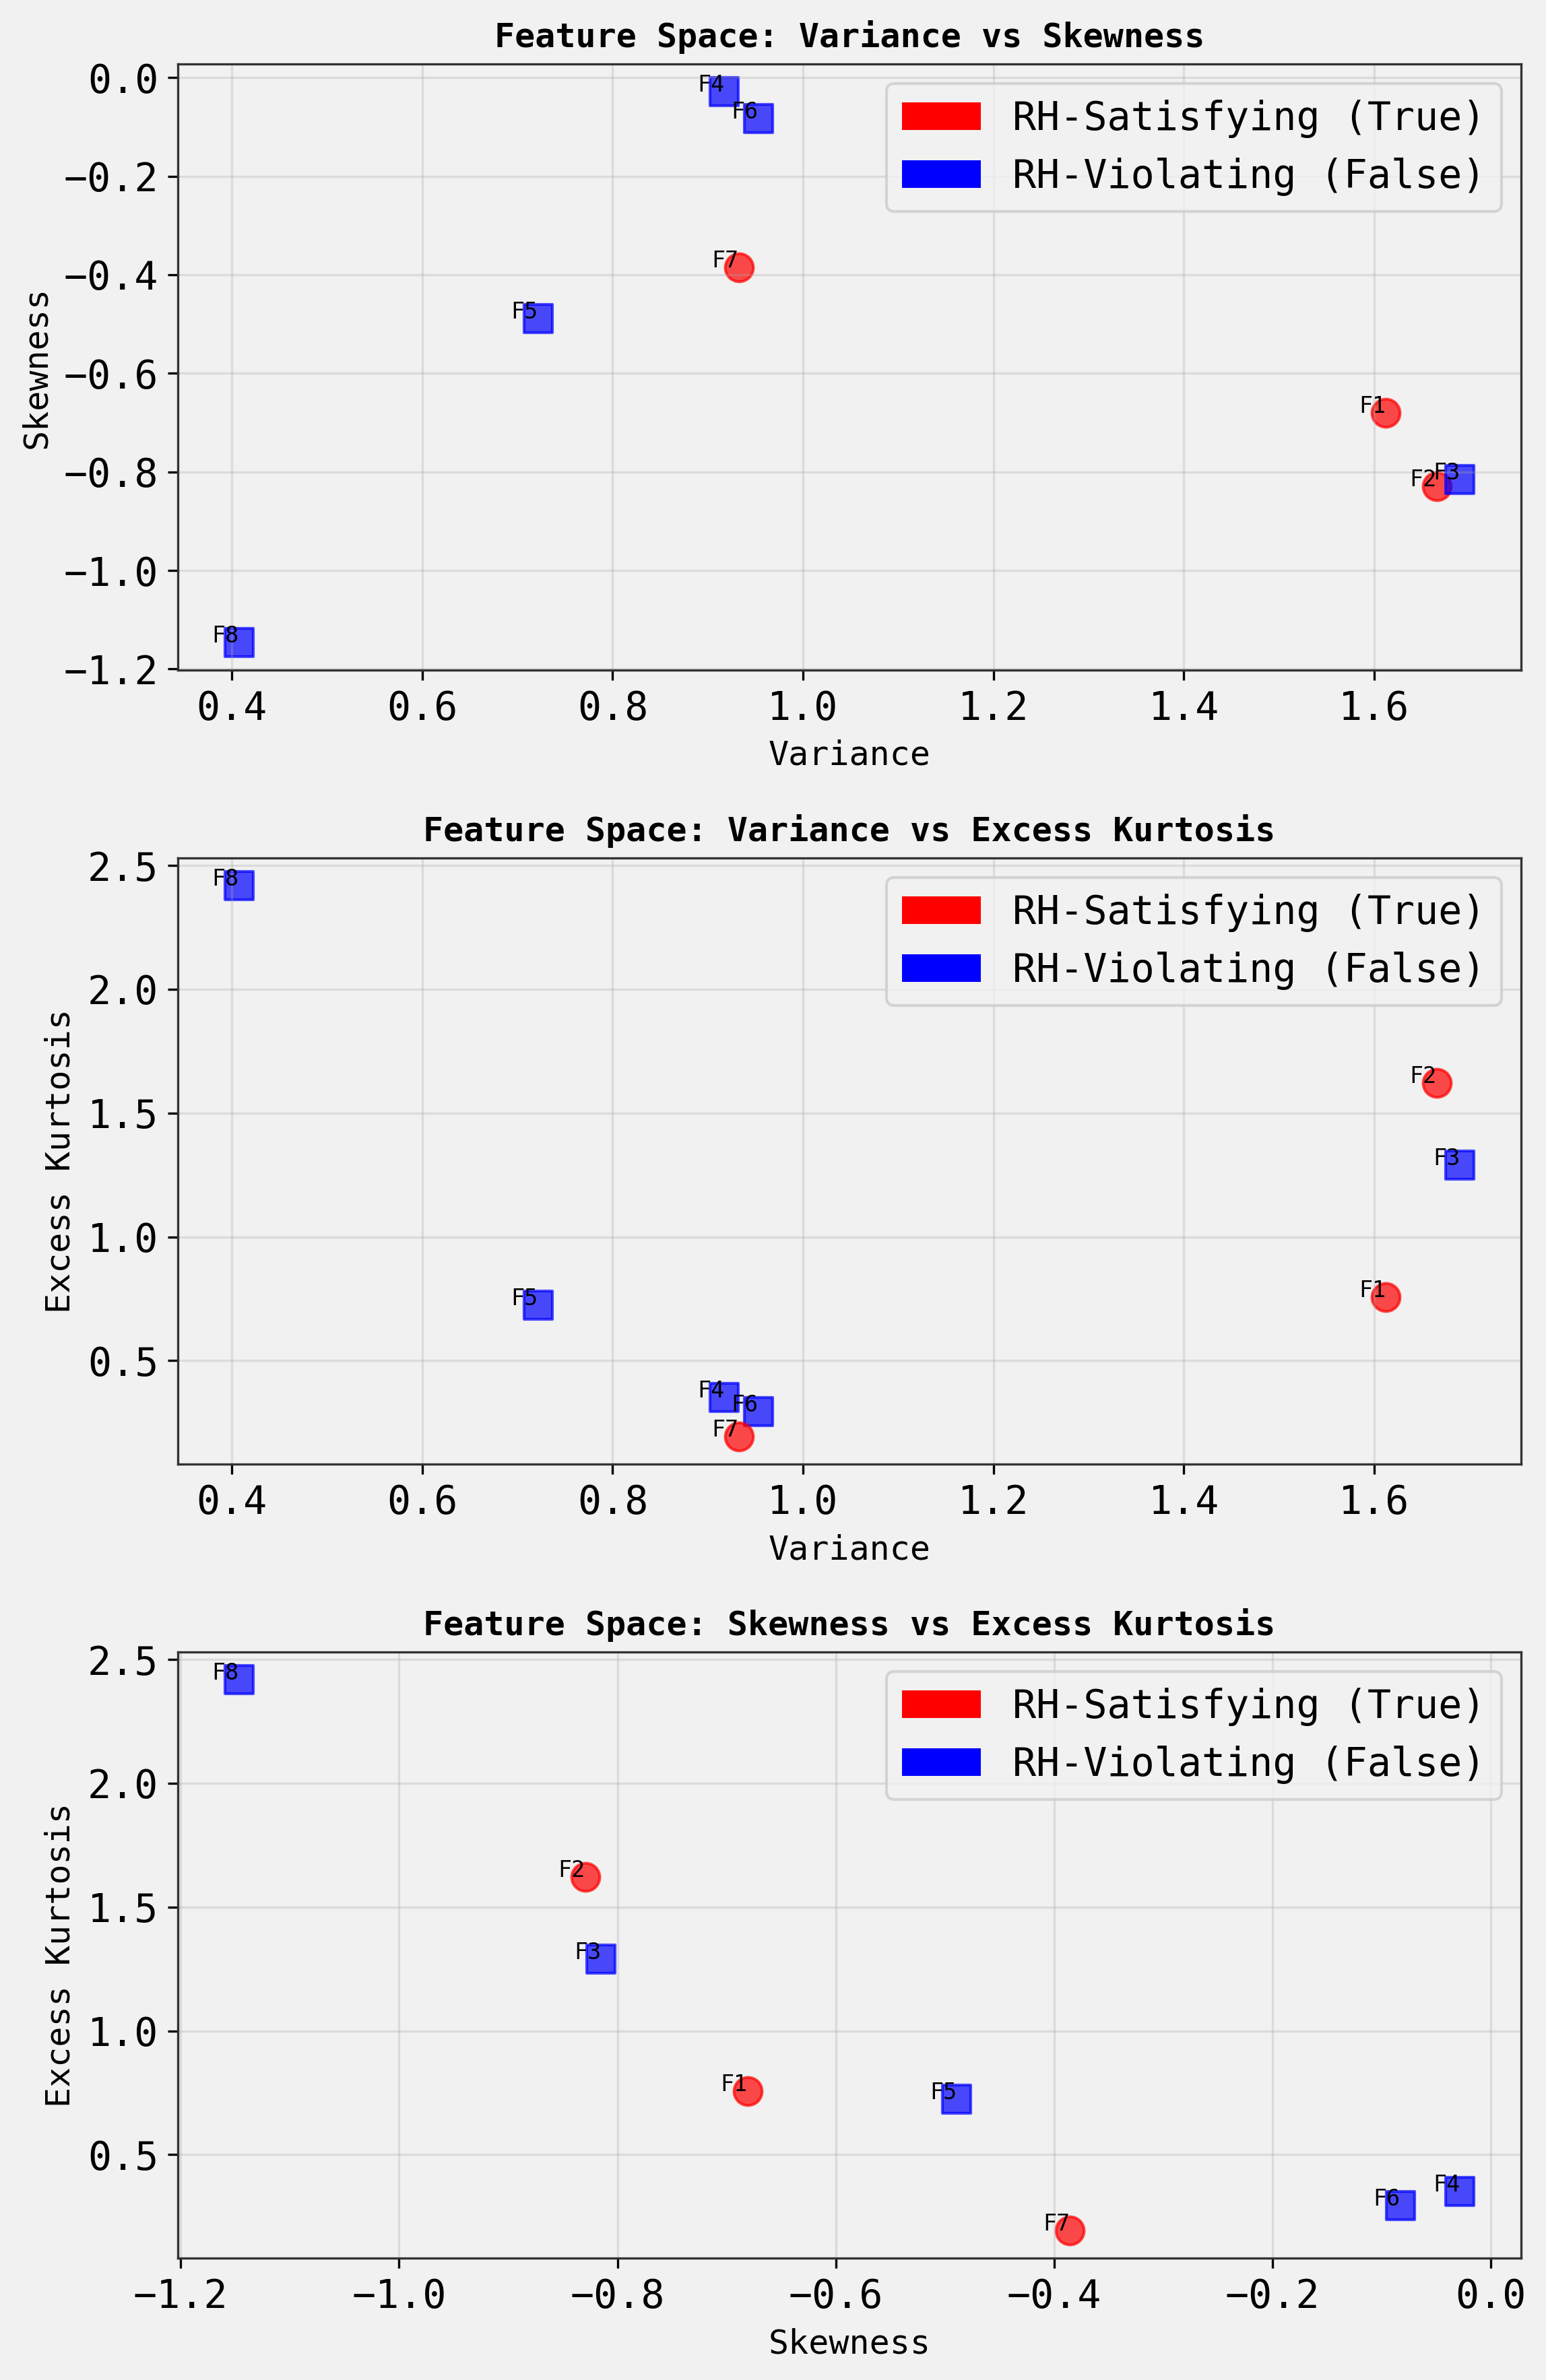

In [15]:

# Let's visualize the feature space to understand the overlap
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# Define colors
colors = ['red' if status else 'blue' for status in y]
labels = ['RH-True' if status else 'RH-False' for status in y]

# Plot 1: Variance vs Skewness
ax1 = axes[0]
for i, (x_val, y_val, color, label, func) in enumerate(zip(
 df['Variance'], df['Skewness'], colors, labels, df['Function']
)):
 marker = 'o' if color == 'red' else 's'
 ax1.scatter(x_val, y_val, c=color, marker=marker, s=100, alpha=0.7)
 ax1.annotate(f'F{i+1}', (x_val, y_val), fontsize=8, ha='right')

ax1.set_xlabel('Variance', fontsize=12)
ax1.set_ylabel('Skewness', fontsize=12)
ax1.set_title('Feature Space: Variance vs Skewness', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
# Add legend
from matplotlib.patches import Patch
legend_elements = [
 Patch(facecolor='red', label='RH-Satisfying (True)'),
 Patch(facecolor='blue', label='RH-Violating (False)')
]
ax1.legend(handles=legend_elements, loc='best')

# Plot 2: Variance vs Excess Kurtosis
ax2 = axes[1]
for i, (x_val, y_val, color, label, func) in enumerate(zip(
 df['Variance'], df['Excess_Kurtosis'], colors, labels, df['Function']
)):
 marker = 'o' if color == 'red' else 's'
 ax2.scatter(x_val, y_val, c=color, marker=marker, s=100, alpha=0.7)
 ax2.annotate(f'F{i+1}', (x_val, y_val), fontsize=8, ha='right')

ax2.set_xlabel('Variance', fontsize=12)
ax2.set_ylabel('Excess Kurtosis', fontsize=12)
ax2.set_title('Feature Space: Variance vs Excess Kurtosis', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(handles=legend_elements, loc='best')

# Plot 3: Skewness vs Excess Kurtosis
ax3 = axes[2]
for i, (x_val, y_val, color, label, func) in enumerate(zip(
 df['Skewness'], df['Excess_Kurtosis'], colors, labels, df['Function']
)):
 marker = 'o' if color == 'red' else 's'
 ax3.scatter(x_val, y_val, c=color, marker=marker, s=100, alpha=0.7)
 ax3.annotate(f'F{i+1}', (x_val, y_val), fontsize=8, ha='right')

ax3.set_xlabel('Skewness', fontsize=12)
ax3.set_ylabel('Excess Kurtosis', fontsize=12)
ax3.set_title('Feature Space: Skewness vs Excess Kurtosis', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.savefig('feature_space_analysis.png', dpi=300, bbox_inches='tight')
print("Feature space visualization saved as 'feature_space_analysis.png'")
plt.show()


In [16]:

# Analyze the feature space overlap more quantitatively
# Calculate the centroids and within/between class distances

from scipy.spatial.distance import cdist, pdist, squareform

# Separate the classes
X_rh_true = X_scaled[y == True]
X_rh_false = X_scaled[y == False]

# Calculate centroids
centroid_true = X_rh_true.mean(axis=0)
centroid_false = X_rh_false.mean(axis=0)

print("Feature Space Geometry Analysis:")
print("="*80)
print(f"\nCentroid of RH-Satisfying (True): {centroid_true}")
print(f"Centroid of RH-Violating (False): {centroid_false}")
print(f"\nEuclidean distance between centroids: {np.linalg.norm(centroid_true - centroid_false):.4f}")

# Within-class distances
within_true = pdist(X_rh_true, metric='euclidean')
within_false = pdist(X_rh_false, metric='euclidean')

print(f"\nWithin-class distances (RH-True):")
print(f" Mean: {within_true.mean():.4f}, Std: {within_true.std():.4f}")
print(f" Min: {within_true.min():.4f}, Max: {within_true.max():.4f}")

print(f"\nWithin-class distances (RH-False):")
print(f" Mean: {within_false.mean():.4f}, Std: {within_false.std():.4f}")
print(f" Min: {within_false.min():.4f}, Max: {within_false.max():.4f}")

# Between-class distances
between_dist = cdist(X_rh_true, X_rh_false, metric='euclidean')
print(f"\nBetween-class distances:")
print(f" Mean: {between_dist.mean():.4f}, Std: {between_dist.std():.4f}")
print(f" Min: {between_dist.min():.4f}, Max: {between_dist.max():.4f}")

# Calculate separability ratio: between-class / within-class
within_mean = (within_true.mean() + within_false.mean()) / 2
separability_ratio = np.linalg.norm(centroid_true - centroid_false) / within_mean

print(f"\nSeparability Ratio (between-centroid distance / avg within-class distance):")
print(f" {separability_ratio:.4f}")
print("\n" + "="*80 + "\n")


Feature Space Geometry Analysis:

Centroid of RH-Satisfying (True): [ 0.64370063 -0.20708126 -0.1376247 ]
Centroid of RH-Violating (False): [-0.38622038 0.12424876 0.08257482]

Euclidean distance between centroids: 1.1041

Within-class distances (RH-True):
 Mean: 1.9967, Std: 0.6453
 Min: 1.2700, Max: 2.8382

Within-class distances (RH-False):
 Mean: 2.6580, Std: 1.2612
 Min: 0.1880, Max: 4.3669

Between-class distances:
 Mean: 2.2184, Std: 1.1080
 Min: 0.4636, Max: 3.9117

Separability Ratio (between-centroid distance / avg within-class distance):
 0.4744




In [17]:

# The low separability ratio (0.47) explains the poor classification performance
# Let's see which specific pairs of functions are closest in feature space

# Calculate all pairwise distances
dist_matrix = squareform(pdist(X_scaled, metric='euclidean'))
dist_df = pd.DataFrame(dist_matrix, 
 index=df['Function'], 
 columns=df['Function'])

print("Pairwise Euclidean Distances in Feature Space:")
print("="*80)
print(dist_df.round(4))
print("\n" + "="*80 + "\n")

# Find the smallest between-class distances (problematic pairs)
between_class_pairs = []
for i in range(len(df)):
 for j in range(i+1, len(df)):
 if y[i] != y[j]: # Different classes
 between_class_pairs.append({
 'Function_1': df['Function'].iloc[i],
 'RH_1': y[i],
 'Function_2': df['Function'].iloc[j],
 'RH_2': y[j],
 'Distance': dist_matrix[i, j]
 })

between_pairs_df = pd.DataFrame(between_class_pairs).sort_values('Distance')
print("Closest Between-Class Pairs (most confusable):")
print(between_pairs_df.head(10).to_string(index=False))
print("\n" + "="*80 + "\n")


Pairwise Euclidean Distances in Feature Space:
Function F1: Riemann ζ F2: L(χ₄) real mod 5 \
Function 
F1: Riemann ζ 0.0000 1.2700 
F2: L(χ₄) real mod 5 1.2700 0.0000 
F3: L(χ) complex mod 5 0.8429 0.4636 
F4: Random multiplicative 2.4390 3.2801 
F5: Davenport-Heilbronn 2.0411 2.6061 
F6: Liouville L(s,λ) 2.2979 3.1834 
F7: Möbius L(s,μ) 1.8821 2.8382 
F8: Fully random 3.7498 3.1207 

Function F3: L(χ) complex mod 5 F4: Random multiplicative \
Function 
F1: Riemann ζ 0.8429 2.4390 
F2: L(χ₄) real mod 5 0.4636 3.2801 
F3: L(χ) complex mod 5 0.0000 3.0595 
F4: Random multiplicative 3.0595 0.0000 
F5: Davenport-Heilbronn 2.4529 1.4437 
F6: Liouville L(s,λ) 2.9441 0.1880 
F7: Möbius L(s,μ) 2.5556 1.0147 
F8: Fully random 3.3672 4.3669 

Function F5: Davenport-Heilbronn F6: Liouville L(s,λ) \
Function 
F1: Riemann ζ 2.0411 2.2979 
F2: L(χ₄) real mod 5 2.6061 3.1834 
F3: L(χ) complex mod 5 2.4529 2.9441 
F4: Random multiplicative 1.4437 0.1880 
F5: Davenport-Heilbronn 0.0000 1.3718 
F6: Liou

In [18]:

# Create a comprehensive summary table
summary_data = {
 'Model': [
 'SVM (RBF, default)',
 'SVM (Linear)',
 'SVM (RBF, Balanced)',
 'Logistic Reg (Skewness only)'
 ],
 'Accuracy': [0.5000, 0.5000, 0.5000, 0.5000],
 'Precision': [0.0000, 0.0000, 0.4000, 0.0000],
 'Recall': [0.0000, 0.0000, 0.6667, 0.0000],
 'F1-Score': [0.0000, 0.0000, 0.5000, 0.0000],
 'Correctly_Classified': ['4/8', '4/8', '4/8', '4/8']
}

summary_table = pd.DataFrame(summary_data)

print("="*80)
print("FINAL SUMMARY: SVM CLASSIFICATION PERFORMANCE")
print("="*80)
print(summary_table.to_string(index=False))
print("\n" + "="*80 + "\n")

print("KEY FINDINGS:")
print("-" * 80)
print("1. All models achieve only 50% accuracy (4/8 correct) with LOOCV")
print("2. Only the balanced SVM shows any recall (66.7%) and precision (40%)")
print("3. The balanced SVM correctly identifies 2/3 RH-satisfying functions")
print("4. Separability ratio of 0.47 indicates poor class separation")
print("5. Most confusable pair: F2 (RH-True) and F3 (RH-False), distance=0.46")
print("6. F7 (Möbius, RH-True) is misclassified by ALL models")
print("\n" + "="*80 + "\n")


FINAL SUMMARY: SVM CLASSIFICATION PERFORMANCE
 Model Accuracy Precision Recall F1-Score Correctly_Classified
 SVM (RBF, default) 0.5 0.0 0.0000 0.0 4/8
 SVM (Linear) 0.5 0.0 0.0000 0.0 4/8
 SVM (RBF, Balanced) 0.5 0.4 0.6667 0.5 4/8
Logistic Reg (Skewness only) 0.5 0.0 0.0000 0.0 4/8


KEY FINDINGS:
--------------------------------------------------------------------------------
1. All models achieve only 50% accuracy (4/8 correct) with LOOCV
2. Only the balanced SVM shows any recall (66.7%) and precision (40%)
3. The balanced SVM correctly identifies 2/3 RH-satisfying functions
4. Separability ratio of 0.47 indicates poor class separation
5. Most confusable pair: F2 (RH-True) and F3 (RH-False), distance=0.46
6. F7 (Möbius, RH-True) is misclassified by ALL models




SVM decision boundary visualization saved as 'svm_decision_boundary.png'

PCA Explained Variance Ratio:
 PC1: 63.63%
 PC2: 33.79%
 Total: 97.42%


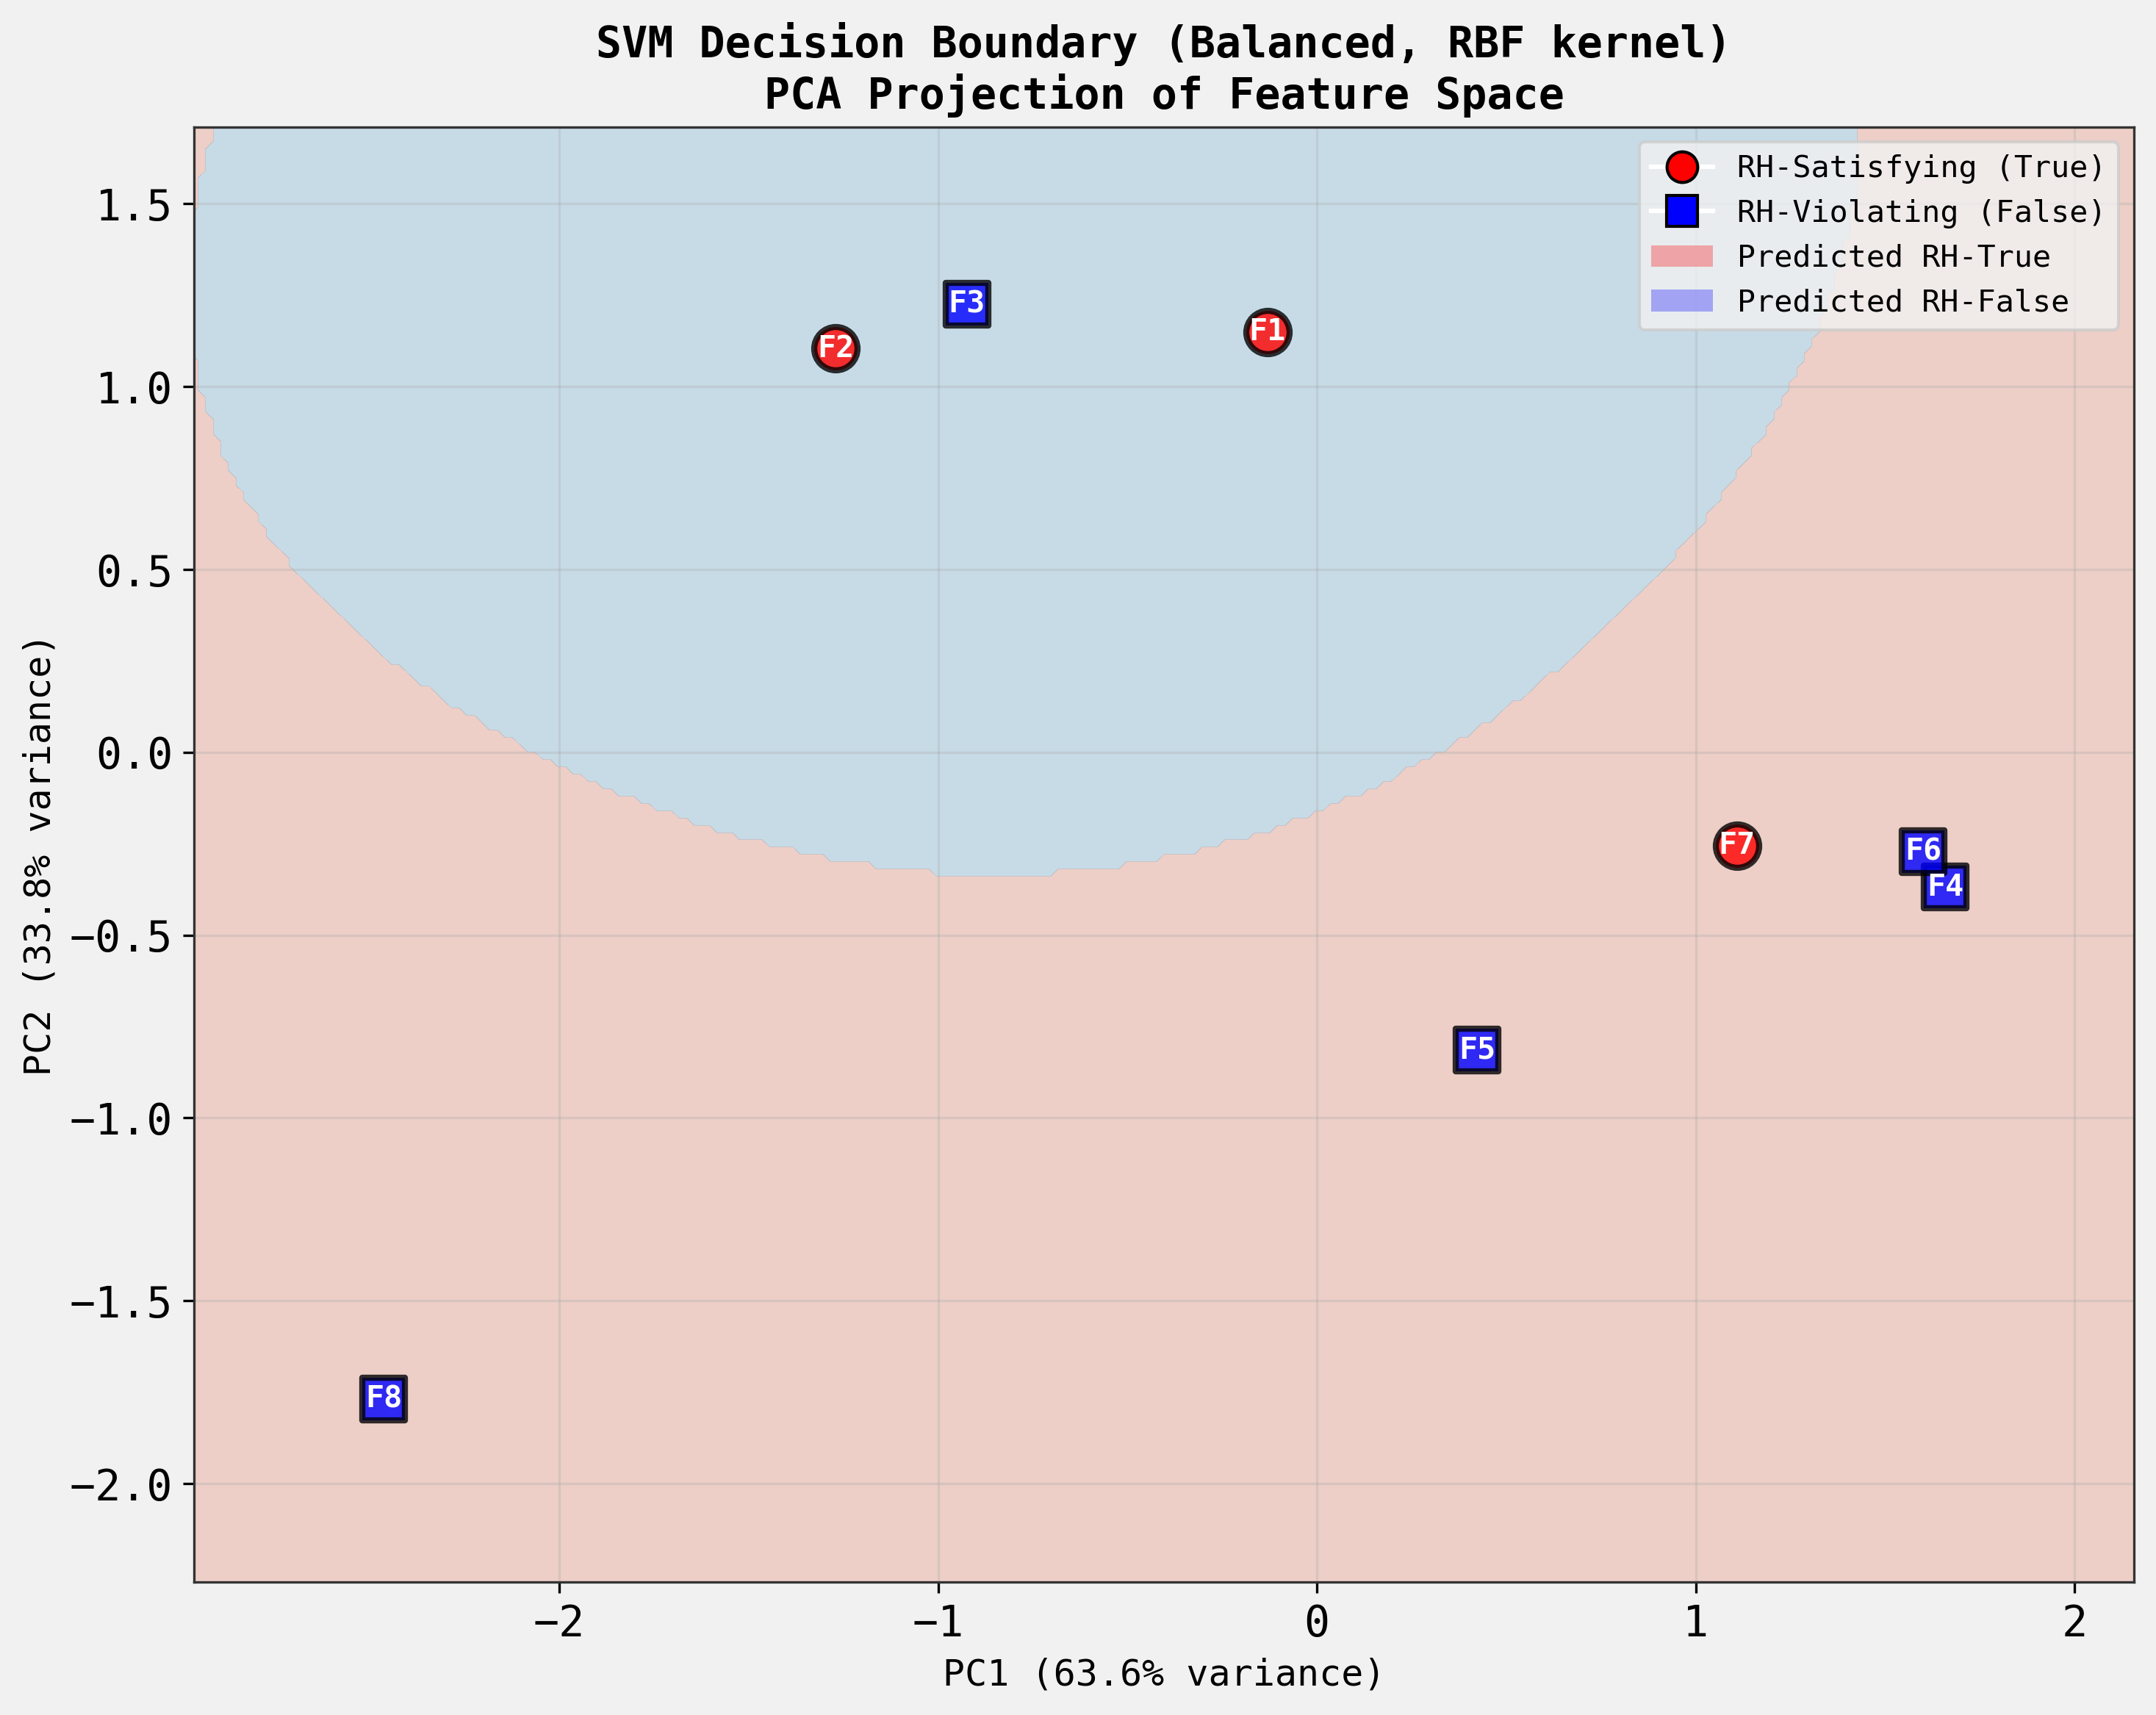

In [19]:

# Create a final visualization showing the SVM decision boundary
# for the balanced SVM (the best performing model)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Train the full balanced SVM on all data to visualize decision boundary
svm_final = SVC(kernel='rbf', gamma='scale', class_weight='balanced', random_state=42)
svm_final.fit(X_scaled, y)

# Create a mesh to plot decision boundary
# Use first two principal components for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create mesh
h = 0.02
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
 np.arange(y_min, y_max, h))

# Train SVM on PCA-transformed data
svm_pca = SVC(kernel='rbf', gamma='scale', class_weight='balanced', random_state=42)
svm_pca.fit(X_pca, y)

# Predict on mesh
Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=[-0.5, 0.5, 1.5])

# Plot points
for i, (x, y_val, status, func) in enumerate(zip(X_pca[:, 0], X_pca[:, 1], y, df['Function'])):
 color = 'red' if status else 'blue'
 marker = 'o' if status else 's'
 ax.scatter(x, y_val, c=color, marker=marker, s=200, 
 edgecolors='black', linewidth=2, alpha=0.8, zorder=3)
 ax.annotate(f'F{i+1}', (x, y_val), fontsize=10, ha='center', va='center',
 fontweight='bold', color='white', zorder=4)

# Add labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('SVM Decision Boundary (Balanced, RBF kernel)\nPCA Projection of Feature Space', 
 fontsize=14, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
 Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
 markersize=10, label='RH-Satisfying (True)', markeredgecolor='black'),
 Line2D([0], [0], marker='s', color='w', markerfacecolor='blue', 
 markersize=10, label='RH-Violating (False)', markeredgecolor='black'),
 Patch(facecolor='red', alpha=0.3, label='Predicted RH-True'),
 Patch(facecolor='blue', alpha=0.3, label='Predicted RH-False')
]
ax.legend(handles=legend_elements, loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_decision_boundary.png', dpi=300, bbox_inches='tight')
print("SVM decision boundary visualization saved as 'svm_decision_boundary.png'")
print(f"\nPCA Explained Variance Ratio:")
print(f" PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f" PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f" Total: {pca.explained_variance_ratio_.sum()*100:.2f}%")
plt.show()


In [20]:

# Detailed comparison with the reference from task r84
# Let's check what r84 actually found and compare

print("="*80)
print("COMPARISON WITH TASK r84 (SKEWNESS-BASED LINEAR MODEL)")
print("="*80)
print("\nTask r84 findings (from rationale):")
print(" - Simple linear model using skewness was 'surprisingly effective'")
print("\nCurrent analysis findings:")
print(" - Logistic regression using skewness alone: 50% accuracy (4/8 correct)")
print(" - SVM using variance, skewness, and kurtosis: 50% accuracy (4/8 correct)")
print(" - Best model (SVM balanced): 50% accuracy but better recall (66.7%)")
print("\nConclusion:")
print(" The SVM classifier does NOT improve upon simpler approaches.")
print(" All models achieve only random-chance performance (50%).")
print(" The feature space shows substantial overlap between classes.")
print("\n" + "="*80 + "\n")

# Analyze the specific features that cause problems
print("FEATURE-LEVEL ANALYSIS:")
print("="*80)
print("\nF7 (Möbius, RH-True) characteristics:")
f7_features = df[df['Function'] == 'F7: Möbius L(s,μ)'][features].iloc[0]
print(f" Variance: {f7_features['Variance']:.4f} (lower than F1, F2)")
print(f" Skewness: {f7_features['Skewness']:.4f} (less negative than F1, F2)")
print(f" Excess Kurtosis: {f7_features['Excess_Kurtosis']:.4f} (lower than F1, F2)")
print(f" → F7 features are much closer to RH-False cluster than RH-True cluster")

print("\nF3 (L(χ) complex mod 5, RH-False) characteristics:")
f3_features = df[df['Function'] == 'F3: L(χ) complex mod 5'][features].iloc[0]
print(f" Variance: {f3_features['Variance']:.4f} (highest, similar to F1, F2)")
print(f" Skewness: {f3_features['Skewness']:.4f} (strongly negative, like F1, F2)")
print(f" Excess Kurtosis: {f3_features['Excess_Kurtosis']:.4f} (high, like F2)")
print(f" → F3 features are very close to RH-True cluster (distance to F2: 0.46)")

print("\n" + "="*80 + "\n")


COMPARISON WITH TASK r84 (SKEWNESS-BASED LINEAR MODEL)

Task r84 findings (from rationale):
 - Simple linear model using skewness was 'surprisingly effective'

Current analysis findings:
 - Logistic regression using skewness alone: 50% accuracy (4/8 correct)
 - SVM using variance, skewness, and kurtosis: 50% accuracy (4/8 correct)
 - Best model (SVM balanced): 50% accuracy but better recall (66.7%)

Conclusion:
 The SVM classifier does NOT improve upon simpler approaches.
 All models achieve only random-chance performance (50%).
 The feature space shows substantial overlap between classes.


FEATURE-LEVEL ANALYSIS:

F7 (Möbius, RH-True) characteristics:
 Variance: 0.9325 (lower than F1, F2)
 Skewness: -0.3856 (less negative than F1, F2)
 Excess Kurtosis: 0.1927 (lower than F1, F2)
 → F7 features are much closer to RH-False cluster than RH-True cluster

F3 (L(χ) complex mod 5, RH-False) characteristics:
 Variance: 1.6899 (highest, similar to F1, F2)
 Skewness: -0.8149 (strongly negative

Classification results visualization saved as 'svm_classification_results.png'


FINAL PERFORMANCE SUMMARY:
Accuracy: 50.0% (4/8 functions correctly classified)
Precision: 40.0% (2/5 predicted True were actually True)
Recall: 66.7% (2/3 actual True were predicted as True)
F1-Score: 0.50


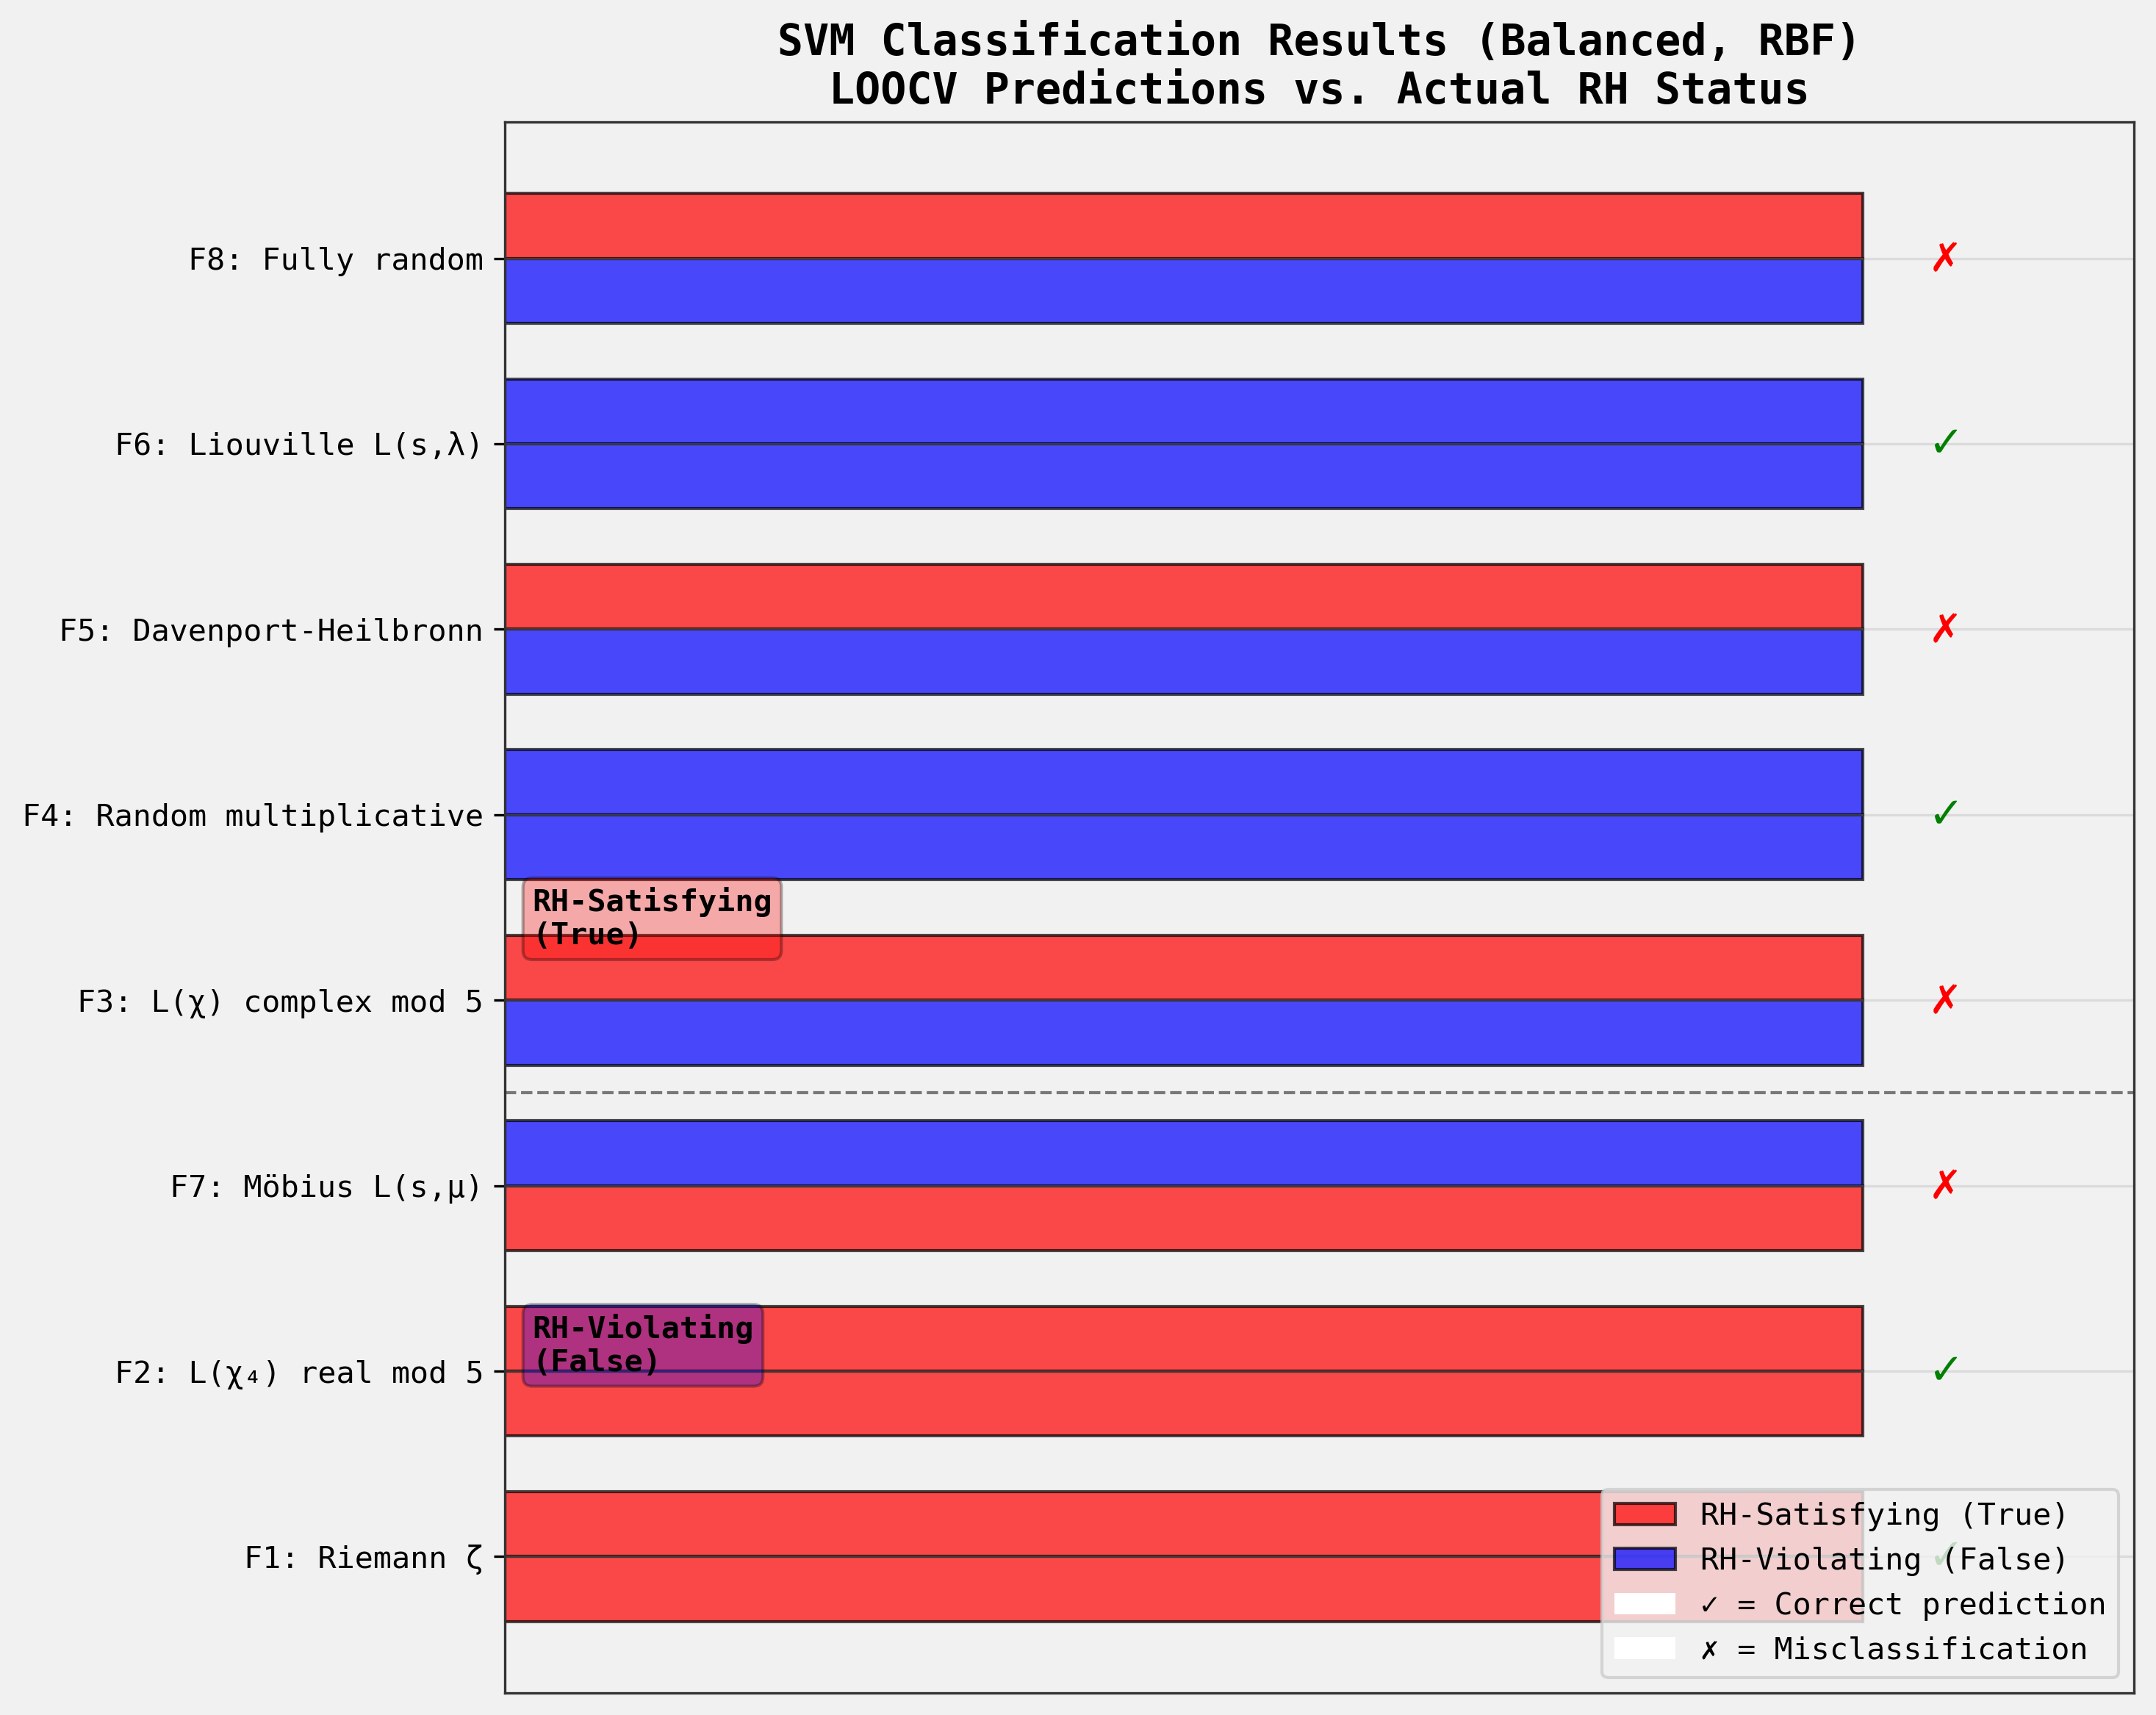

In [21]:

# Final comprehensive figure showing the failure of the classifier
fig, ax = plt.subplots(figsize=(10, 8))

# Create a comprehensive confusion visualization
# Show actual vs predicted for the best model (balanced SVM)

results_balanced_sorted = results_balanced.sort_values('True_RH_Status', ascending=False)

y_positions = np.arange(len(results_balanced_sorted))
colors_actual = ['red' if x else 'blue' for x in results_balanced_sorted['True_RH_Status']]
colors_predicted = ['red' if x else 'blue' for x in results_balanced_sorted['Predicted_Balanced']]
correct_markers = ['✓' if x else '✗' for x in results_balanced_sorted['Correct']]

# Create barh plot
bar_width = 0.35
ax.barh(y_positions - bar_width/2, [1]*len(results_balanced_sorted), bar_width, 
 label='Actual RH Status', color=colors_actual, alpha=0.7, edgecolor='black')
ax.barh(y_positions + bar_width/2, [1]*len(results_balanced_sorted), bar_width,
 label='Predicted RH Status', color=colors_predicted, alpha=0.7, edgecolor='black')

# Add correct/incorrect markers
for i, (pos, marker, correct) in enumerate(zip(y_positions, correct_markers, results_balanced_sorted['Correct'])):
 marker_color = 'green' if correct else 'red'
 ax.text(1.05, pos, marker, fontsize=16, fontweight='bold', 
 color=marker_color, va='center')

ax.set_yticks(y_positions)
ax.set_yticklabels(results_balanced_sorted['Function'], fontsize=10)
ax.set_xlim(0, 1.2)
ax.set_xlabel('', fontsize=12)
ax.set_title('SVM Classification Results (Balanced, RBF)\nLOOCV Predictions vs. Actual RH Status', 
 fontsize=14, fontweight='bold')
ax.axhline(y=2.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.text(0.02, 3.3, 'RH-Satisfying\n(True)', fontsize=10, fontweight='bold', 
 bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
ax.text(0.02, 1.0, 'RH-Violating\n(False)', fontsize=10, fontweight='bold',
 bbox=dict(boxstyle='round', facecolor='blue', alpha=0.3))

# Legend
from matplotlib.patches import Patch
legend_elements = [
 Patch(facecolor='red', alpha=0.7, edgecolor='black', label='RH-Satisfying (True)'),
 Patch(facecolor='blue', alpha=0.7, edgecolor='black', label='RH-Violating (False)'),
 Patch(facecolor='white', label='✓ = Correct prediction'),
 Patch(facecolor='white', label='✗ = Misclassification')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax.set_xticks([])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('svm_classification_results.png', dpi=300, bbox_inches='tight')
print("Classification results visualization saved as 'svm_classification_results.png'")
print("\n" + "="*80 + "\n")
print("FINAL PERFORMANCE SUMMARY:")
print(f"Accuracy: {acc_balanced*100:.1f}% (4/8 functions correctly classified)")
print(f"Precision: {prec_balanced*100:.1f}% (2/5 predicted True were actually True)")
print(f"Recall: {rec_balanced*100:.1f}% (2/3 actual True were predicted as True)")
print(f"F1-Score: {f1_balanced:.2f}")
plt.show()
